# Homework 11


**Concepts covered:**

pandas `DataFrame`s: grouping data, querying `DataFrame`s, joining multiple `DataFrame`s, sampling.

**Instructions:**

Be sure to run each code block after you edit it to make sure it runs as expected. When you are done, we strongly recommend you run all the code from scratch (Runtime menu -> Restart and Run all) to make sure your current code works for all problems.

If your code raises an exception when run from scratch, it will interfere with the auto-grader process causing you to lose some or all points for this homework. Please ask for help on Piazza, attend office hours or schedule an appointment with your learning facilitator if you get stuck.

**Warning about AI:**

It is **strictly forbidden to use any generative AI (e.g., ChatGPT, Claude, Gemini, CoPilot or any similar tools**) to write solutions for any assignment. Students who submit work that is not authentically their own individual work will earn a grade of 0 on this assignment.


**Docstrings and Comments:**

Include a *documentation string* (docstring) for each function definition, as well as comments in the body of your code to explain each control structures (e.g., decision, loop), function call, or formula.

## Shared Imports

Do not install or use any additional modules.
Installing additional modules may result in an autograder failure resulting in zero points for some or all problems.

In [17]:
# shared imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.close("all")


**Note: This assignment is partially manually graded, so please allow some time for you to get your final scores.**

**Review Problem 1**

**Concept:** *`DataFrame`: initialization, line plots.*

**Task:**


Using the Starbucks stock dataset:

1. Load the `SBUX.csv` dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Create a line plot showing both the `high` and `low` prices over time.

Your plot should include:

* both high and low columns plotted together
* a title
* a key


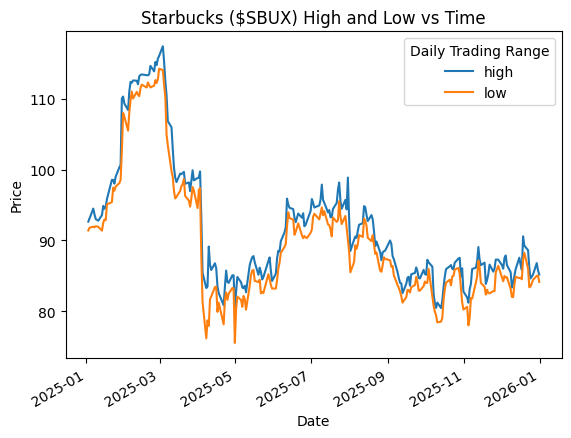

In [51]:
# Your Solution



df_sbux = pd.read_csv('SBUX.csv')

df_sbux["date"] = pd.to_datetime(df_sbux["date"] ,unit= 's')
df_sbux = df_sbux.set_index("date")



df_sbux[['high','low']].plot()

plt.title('Starbucks ($SBUX) High and Low vs Time')
plt.legend(title = 'Daily Trading Range')
plt.ylabel('Price')
plt.xlabel('Date')
plt.show()

Review Problem 2

**Concept:** *`DataFrame`: initialization, descriptive statistics, histogram.*

**Task:**

Using the `SBUX.csv` dataset:

1. Load the dataset into a DataFrame named `df_sbux`.
2. Convert the `date` column to a pandas datetime format and set it as the index.
3. Compute the **daily return** of the stock using the `close` column (percentage change).
4. Display the **descriptive statistics** of the daily returns.
5. Create a **histogram** of the daily returns using 25 bins.
6. Identify **outliers** where the return falls outside of **mean ± 3 standard deviations**.
7. Print:
    *  the upper and lower bounds
    * the number of values above and below these bounds
    * the list of outlier values (sorted by date)


Descriptive Statistics:
count    249.000000
mean      -0.013012
std        2.160067
min      -11.216177
25%       -1.133576
50%        0.010747
75%        1.132297
max       11.281212
Name: daily_return, dtype: float64


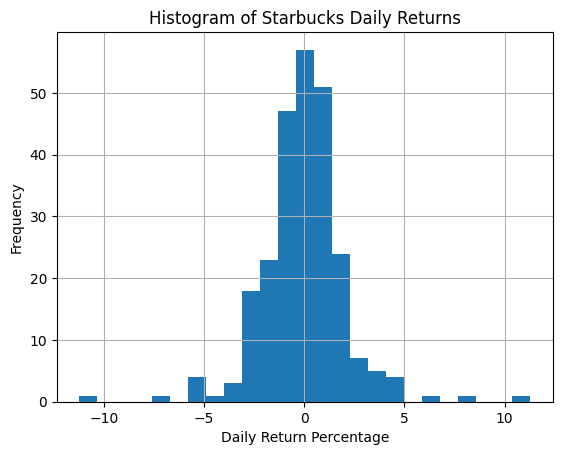

upper bound: 6.467188888830805
lower bound: -6.493212818695373

number of values below upper bound: 3 
number of values below lower bound: 2

Outlier Values by date:
                    formatted_date        high         low        open  \
date                                                                     
2025-01-29 14:30:00     2025-01-29  110.080002  102.680000  102.699997   
2025-04-03 13:30:00     2025-04-03   93.389999   87.650002   93.349998   
2025-04-04 13:30:00     2025-04-04   85.430000   81.300003   84.660004   
2025-04-09 13:30:00     2025-04-09   89.129997   77.930000   79.220001   
2025-05-12 13:30:00     2025-05-12   86.540001   83.639999   83.650002   

                          close    volume    adjclose  daily_return  
date                                                                 
2025-01-29 14:30:00  108.580002  40769300  105.771851      8.136638  
2025-04-03 13:30:00   88.260002  20490100   86.444016    -11.216177  
2025-04-04 13:30:00   82.099998  19

In [ ]:
# Your Solution


## Plotting 
df_sbux = pd.read_csv('SBUX.csv')

df_sbux["date"] = pd.to_datetime(df_sbux["date"] ,unit= 's')
df_sbux = df_sbux.set_index("date")

df_sbux['daily_return'] = df_sbux['close'].pct_change() * 100 # calculating the percent change from the close column in percentage units 

print(f'Descriptive Statistics:\n{df_sbux['daily_return'].describe()}') # displaying descriptive stats for the ticker 

df_sbux["daily_return"].hist(bins=25)
plt.title('Histogram of Starbucks Daily Returns')
plt.xlabel('Daily Return Percentage')
plt.ylabel('Frequency')
plt.show()



### Calculating std, mean and lower bounds

daily_return_std = df_sbux['daily_return'].std()
daily_return_mean = df_sbux['daily_return'].mean()


lower_bound = daily_return_mean - (3 * daily_return_std)
upper_bound = daily_return_mean + (3 * daily_return_std)

### Defining the outliers as returns above lower and upper bound calculations and returning the values from the original dataframe
above_outlier_values = df_sbux[df_sbux['daily_return'] > upper_bound]
below_outlier_values = df_sbux[df_sbux['daily_return'] < lower_bound]

# adding all outliers to one dataframe to print in the end
all_outliers = pd.concat([above_outlier_values, below_outlier_values]).sort_index() # since date is the index, this sorts by date


print(f'upper bound: {upper_bound}\nlower bound: {lower_bound}\n')
print(f'number of values below upper bound: {len(above_outlier_values)} \nnumber of values below lower bound: {len(below_outlier_values)}\n')
print(f'Outlier Values by date:\n{all_outliers}')


Test case for problem 2

In [67]:
# Test Case:




print(upper_bound, above_outlier_values['daily_return'],'\n')
print(lower_bound, below_outlier_values['daily_return'])

# total of 5 values that are displayed in the above code


df_sbux[['close','daily_return']].sort_values(by = 'daily_return', ascending= False)





6.467188888830805 date
2025-01-29 14:30:00     8.136638
2025-04-09 13:30:00    11.281212
2025-05-12 13:30:00     6.687416
Name: daily_return, dtype: float64 

-6.493212818695373 date
2025-04-03 13:30:00   -11.216177
2025-04-04 13:30:00    -6.979383
Name: daily_return, dtype: float64


,close,daily_return
date,,
2025-04-09 13:30:00,88.680000,11.281212
2025-01-29 14:30:00,108.580002,8.136638
2025-05-12 13:30:00,85.669998,6.687416
2025-12-18 14:30:00,89.419998,4.940734
2025-07-22 13:30:00,96.940002,4.619036
...,...,...
2025-03-06 14:30:00,105.470001,-5.568987
2025-04-30 13:30:00,80.050003,-5.657037
2025-04-04 13:30:00,82.099998,-6.979383


**Problem 3**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Load the dataset into a DataFrame named `df_weather`.
2. Convert the `datetime` column to a pandas datetime format and set it as the index.
3. Use the icon column as a categorical variable and group the data by `icon`.
4. Create a **pie chart** showing the count of each weather icon category.

Your chart should include:
* labels for each category
* a title



/var/folders/mv/spx6wvr963x933gjcq0392n80000gn/T/ipykernel_44193/442467921.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])


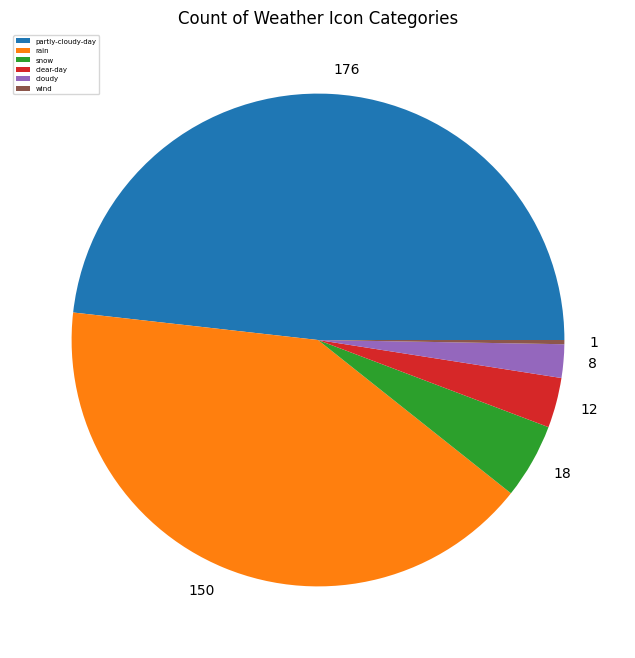

icon
partly-cloudy-day    176
rain                 150
snow                  18
clear-day             12
cloudy                 8
wind                   1
Name: count, dtype: int64

In [136]:
# Your Solution

df_weather = pd.read_csv("02215_weather.csv")
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])
df_weather = df_weather.set_index("datetime") # setting the index of the dataset

icon_counts = df_weather["icon"].value_counts()

plt.figure(figsize=(16,8))
plt.pie(icon_counts, labels=icon_counts) # labels the data with the counts of the icons as requested
plt.title("Count of Weather Icon Categories")
plt.legend(icon_counts.index,fontsize = 5, loc = 'upper left')
plt.show()

icon_counts


**Problem 4**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a **histogram** of the `tempmax` column for each weather condition group.

Your plot should include:
* 25 bins
* transparency so overlapping distributions can be seen
* a legend
* a title


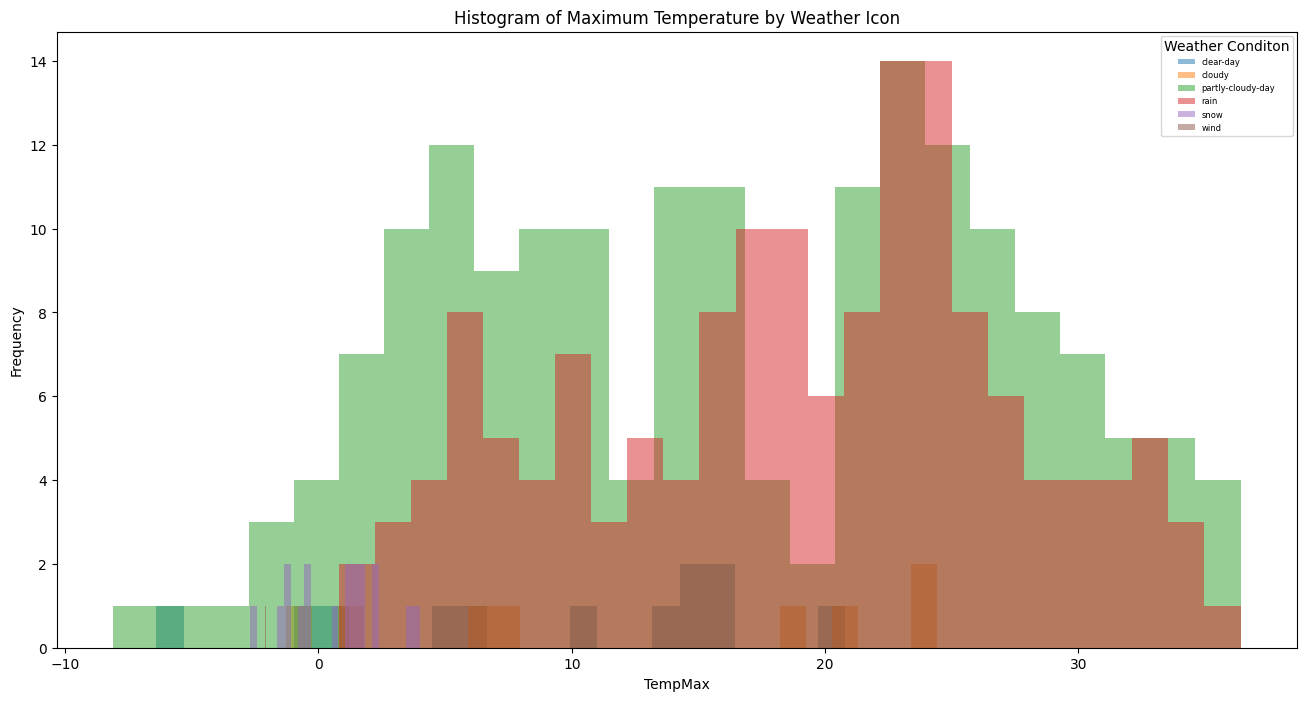

In [133]:
# Your Solution

weather_groups = df_weather.groupby('icon')



plt.figure(figsize=(16,8))

for icon, group in weather_groups:
    plt.hist(group["tempmax"], bins=25, alpha=0.5, label=icon)

plt.legend(fontsize = 6, title = 'Weather Conditon')
plt.xlabel('TempMax')
plt.ylabel('Frequency')
plt.title("Histogram of Maximum Temperature by Weather Icon")
plt.show()



**Problem 5**

**Concept:** *Grouping Data, plotting*


**Task:**

Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Create a histogram of the `precip` column for each weather condition group.

Your plot should include:

* 10 bins
* transparency so overlapping distributions can be seen
* a legend
* a title



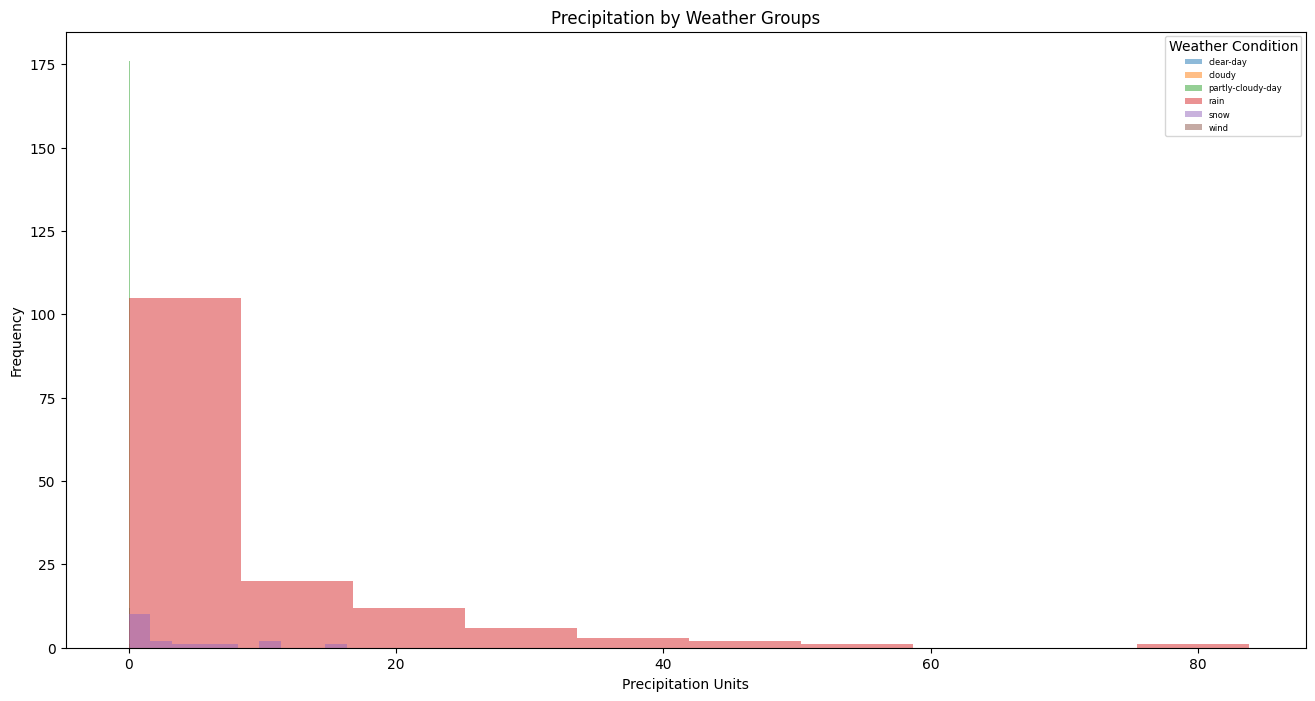

In [137]:
# Your Solution

plt.figure(figsize=(16,8))

for icon, group in weather_groups: 
    plt.hist(group['precip'], bins = 10, alpha = 0.5, label= icon) # using the same grouping as above, and plotting 

plt.title('Precipitation by Weather Groups')
plt.xlabel('Precipitation Units')
plt.ylabel('Frequency')
plt.legend(title = 'Weather Condition', fontsize = 6)
plt.show()



**Problem 6**

**Concept:** *Grouping Data, plotting*


**Task:**


Using the `02215_weather.csv` dataset:

1. Use the existing grouped object based on the `icon` column from **Problem 3**.
2. Compute the **mean** of the `tempmax` column for each weather condition group.
3. Create a **bar chart** to display the mean maximum temperature for each group.


Your plot should include:

* one bar for each weather icon category
* a title



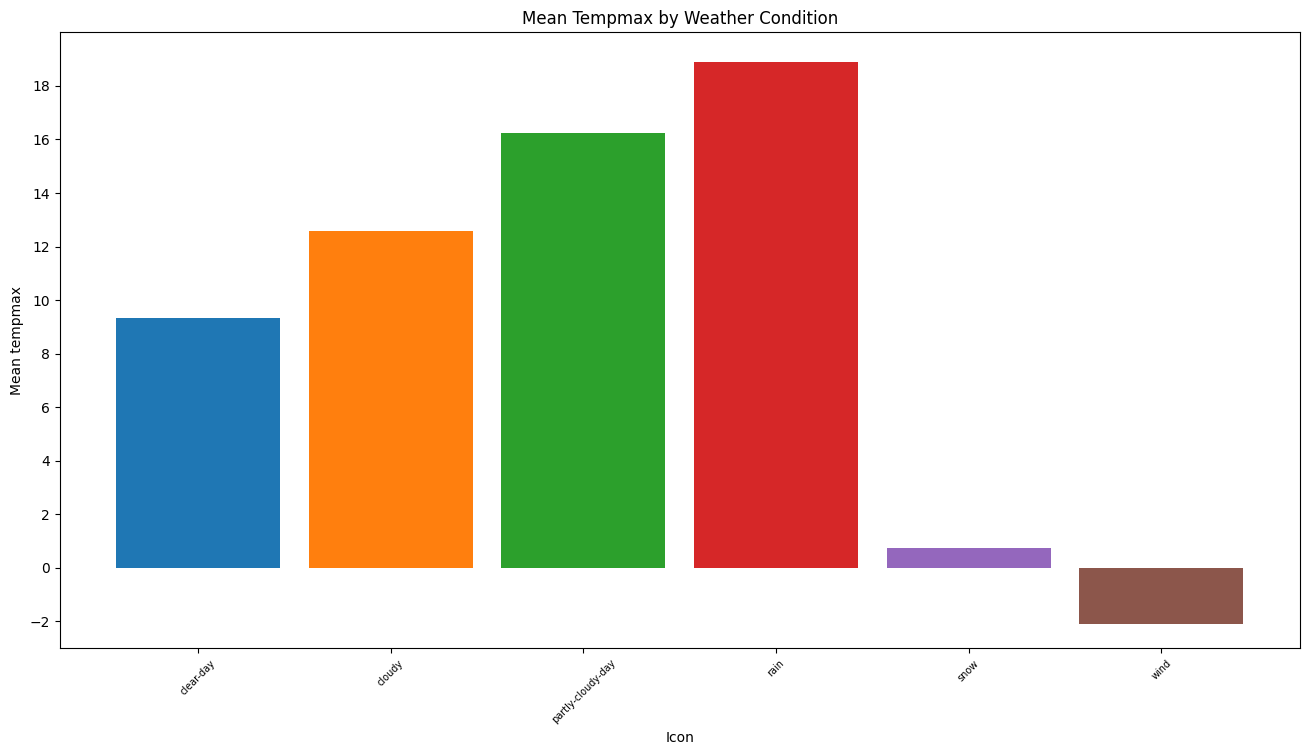

In [138]:
# Your Solution
weather_groups_means = weather_groups['tempmax'].mean() # calculating the mean max temp for each weather group

plt.figure(figsize=(16,8))

for icon, mean_val in weather_groups_means.items():  #adding each of the groups weather condition and values to the plot 
    plt.bar(icon, mean_val, width= 0.85)

plt.title('Mean Tempmax by Weather Condition')
plt.xlabel('Icon')
plt.ylabel('Mean tempmax')
plt.xticks(fontsize = 7,rotation = 45)
plt.yticks(range(-2,20,2))
plt.ylim(-3,20)
plt.show()




**Problem 7**

**Concept:** *Grouping data, descriptive statistics*


**Task:**

Using the `02215_weather.csv` dataset:

1. Group the DataFrame by the `icon` column and store the result in a variable named `grouped_by_icon`.
2. Compute descriptive statistics for the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_statistics`.
3. Compute descriptive statistics for the `precip` column for each group and store the result in a variable named `grouped_precipitation_statistics`.
4. Compute the **mean** of the `tempmax` column for each group and store the result in a variable named `grouped_tempmax_mean`.

Print all three results with clear labels:
* `"Tempmax grouped by conditions"`
* `"Precipitation grouped by conditions"`
* `"Mean of tempmax grouped by conditions"`


In [139]:
# Your Solution


grouped_by_icon = df_weather.groupby('icon')

grouped_tempmax_statistics = grouped_by_icon['tempmax'].describe()
grouped_precipitation_statistics = grouped_by_icon['precip'].describe()

grouped_tempmax_mean = grouped_by_icon['tempmax'].mean() # mean of the tempmax column 

print(f'Tempmax grouped by conditions: \n {grouped_tempmax_statistics}\n')
print(f'Precipitation grouped by conditions: \n {grouped_precipitation_statistics}\n')
print(f'Mean of tempmax grouped by conditions:{grouped_tempmax_mean}')





Tempmax grouped by conditions: 
                    count       mean        std  min    25%    50%     75%  \
icon                                                                        
clear-day           12.0   9.316667   8.230965 -6.4   4.15  12.10  15.225   
cloudy               8.0  12.575000  10.423565 -1.3   4.95  13.05  21.350   
partly-cloudy-day  176.0  16.246023  10.533554 -8.1   7.20  15.65  25.000   
rain               150.0  18.904000   8.498037  0.8  12.60  19.90  24.600   
snow                18.0   0.750000   1.805628 -2.7  -0.65   1.25   1.775   
wind                 1.0  -2.100000        NaN -2.1  -2.10  -2.10  -2.100   

                    max  
icon                     
clear-day          20.8  
cloudy             24.4  
partly-cloudy-day  36.4  
rain               36.4  
snow                4.0  
wind               -2.1  

Precipitation grouped by conditions: 
                    count      mean        std    min      25%     50%  \
icon                         

QUERYING

The following data frame will be used in several questions.


In [ ]:
# starter code
df_voter_data = pd.read_csv("https://raw.githubusercontent.com/bu-cds-dx602/homework/main/week-11/newton_voters.csv", low_memory=False)
df_voter_data.index = df_voter_data["Voter ID Number"]
df_voter_data['Date of Birth'] = pd.to_datetime(df_voter_data['Date of Birth'])


**Problem 8**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Determine the **total number of voters** and print the result.
2. Compute the count of voters in each **Party Affiliation** category.
3. Create a **pie chart** showing the distribution of voters by party affiliation.

Your plot should include:
* labels for each category
* a title that includes the total number of voters


/var/folders/mv/spx6wvr963x933gjcq0392n80000gn/T/ipykernel_44193/1154291735.py:3: DtypeWarning: Columns (0: Precinct Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df_voter_data = pd.read_csv('newton_voters.csv')


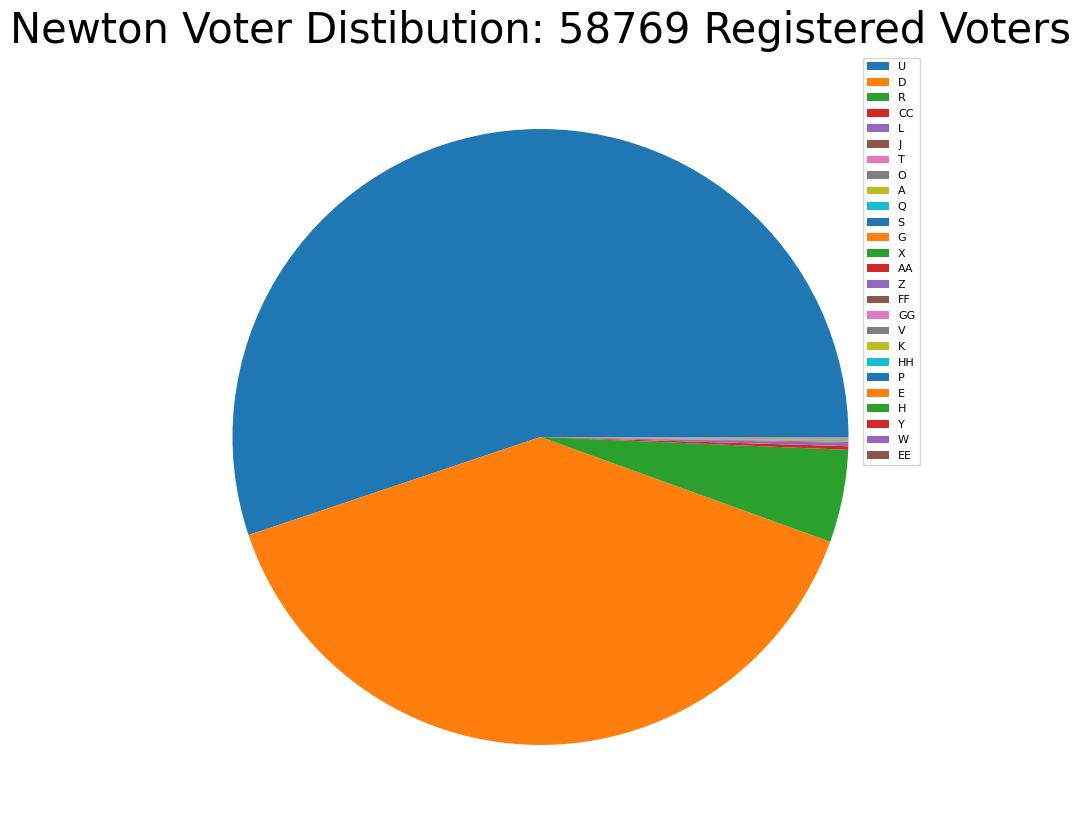

Party Affiliation
U     32416
D     23108
R      2854
CC      110
L       103
J        28
T        27
O        22
A        20
Q        19
S        14
G        10
X         8
AA        7
Z         5
FF        4
GG        3
V         2
K         2
HH        1
P         1
E         1
H         1
Y         1
W         1
EE        1
Name: count, dtype: int64

In [ ]:
# Your Solution

df_voter_data = pd.read_csv('newton_voters.csv')
df_voter_data.index = df_voter_data["Voter ID Number"]
df_voter_data['Date of Birth'] = pd.to_datetime(df_voter_data['Date of Birth'])


number_of_voters = len(df_voter_data['Voter ID Number'])

number_of_voters

party_affiliation_grouping = df_voter_data.groupby('Party Affiliation')

party_affiliation_counts = df_voter_data['Party Affiliation'].value_counts() # calculating the number of party affliations in the whole data set

party_affiliation_counts


plt.figure(figsize=(20,10))
plt.pie(party_affiliation_counts)
plt.legend(party_affiliation_counts.index, fontsize = 8, loc = 'upper right')
plt.title(f'Newton Voter Distibution: {number_of_voters} Registered Voters', fontsize = 30)
plt.show()


# party_affiliation_counts_confined = party_affiliation_counts[party_affiliation_counts > 2000] in case we want to confine the values 


**Problem 9**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_older_voters` that includes only voters born **before January 1, 1950**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these older voters.

Your plot should include:
* labels for each category
* a title that includes the number of older voters


Total Number of Voters:  9073


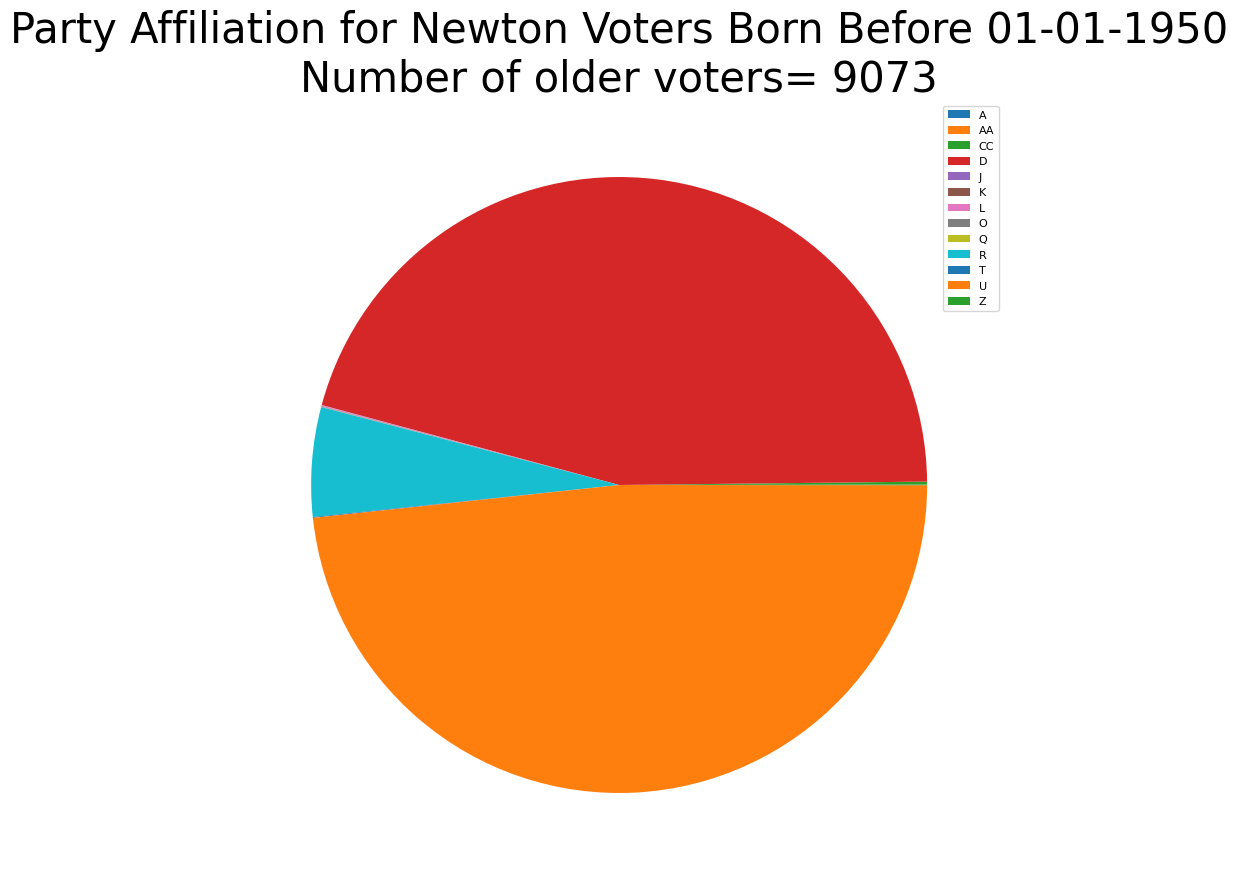

In [114]:
# Your Solution
df_voter_data['Date of Birth'] =pd.to_datetime(df_voter_data['Date of Birth']) # overwriting the DOB column and converting to datetime using pandas

df_older_voters = df_voter_data.query("`Date of Birth` < '1950-01-01'")

print('Total Number of Voters: ', len(df_older_voters))

party_affiliation_grouping = df_older_voters.groupby('Party Affiliation')

party_affiliation_counts= party_affiliation_grouping['Party Affiliation'].value_counts()

party_affiliation_counts

plt.figure(figsize=(20,10))
plt.pie(party_affiliation_counts)
plt.legend(party_affiliation_counts.index, fontsize = 8)
plt.title(f'Party Affiliation for Newton Voters Born Before 01-01-1950\nNumber of older voters= {len(df_older_voters)}', fontsize =30)
plt.show()


**Problem 10**

**Concept:** *Querying `DataFrame`s and graphing*


**Task:**

Using the `df_voter_data` DataFrame:
1. Create a new DataFrame named `df_younger_voters` that includes only voters born **after January 1, 2000**.
    * Use the `.query()` method
    * Note: use backticks for column names containing spaces
2. Print the total number of voters in this filtered dataset.
3. Compute the count of voters in each **Party Affiliation** category for this subset.
4. Create a **pie chart** showing the distribution of party affiliations among these Younger voters.

Your plot should include:
* labels for each category
* a title that includes the number of younger voters


Total Number of Younger Voters:  5099


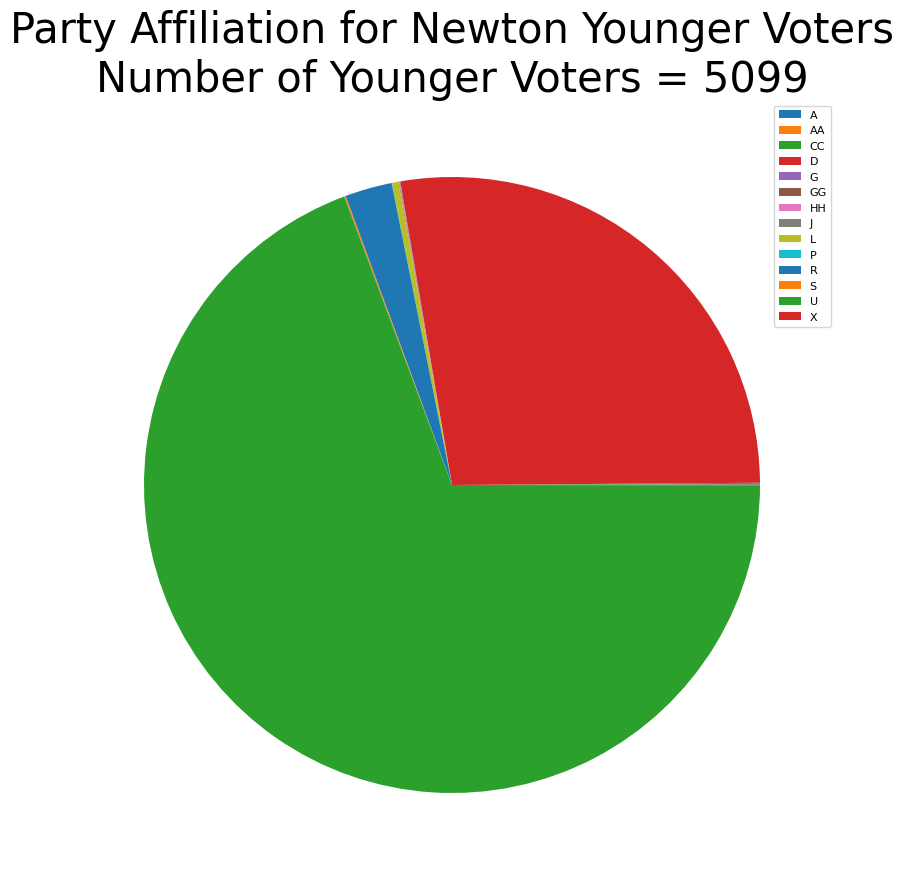

In [111]:
# Your Solution


df_younger_voters = df_voter_data.query("`Date of Birth` > '2000-01-01'") # if the column you are selecting has a space, use the `` to select. Then use quotes '' for the date of the query  
print('Total Number of Younger Voters: ', len(df_younger_voters))

younger_voters_party_affiliation_grouping = df_younger_voters.groupby('Party Affiliation')

younger_voters_counts = younger_voters_party_affiliation_grouping['Party Affiliation'].value_counts()

plt.figure(figsize=(20,10))
plt.pie(younger_voters_counts)
plt.legend(younger_voters_counts.index, fontsize = 8)
plt.title(f'Party Affiliation for Newton Younger Voters\nNumber of Younger Voters = {len(df_younger_voters)}', fontsize =30)
plt.show()


**Problem 11**

**Concept:** *Querying `DataFrame`s and graphing*



**Task:**

Using the `df_voter_data` DataFrame:
1. Identify all columns related to elections:
    * Select columns whose names contain the letter `"v"` but do **not** contain `"score"`
    * Store the result in a variable named `election_columns`

2. Compute the **voting participation percentage** for each election among all voters:
    * Store the result in a variable named `d1`
    * **Hint:** To calculate participation
        * Use `.sum()` on a column to count how many voters participated
        * Divide by the total number of voters using `len(df)`
        * Multiply by 100 to convert to a percentage

3. Create a filtered DataFrame named `df_high_voter_score`:
    * Include only voters with `voter_score >= 4`
    * Print the number of voters in this group

4. Compute the **voting participation percentage** for this group:
    * Store the result in a variable named `d2`

5. Create a filtered DataFrame named `df_unenrolled`:
    * Include only voters with `"Party Affiliation" == "U "`
    * Print the number of voters in this group

6. Compute the voting participation percentage for this group:
    * Store the result in a variable named `d3`

7. Combine the results into a new DataFrame named `d`:
    * Index should be the election columns
    * Columns should be:
        * `"all voters"`
        * `"high-propensity voters"`
        * `"unenrolled voters"`

8. Create a **bar chart** from this combined DataFrame.

Your plot should include:
* a title
* a key

Number of High Voter Score: 15245
Number of Unenrolled: 32416


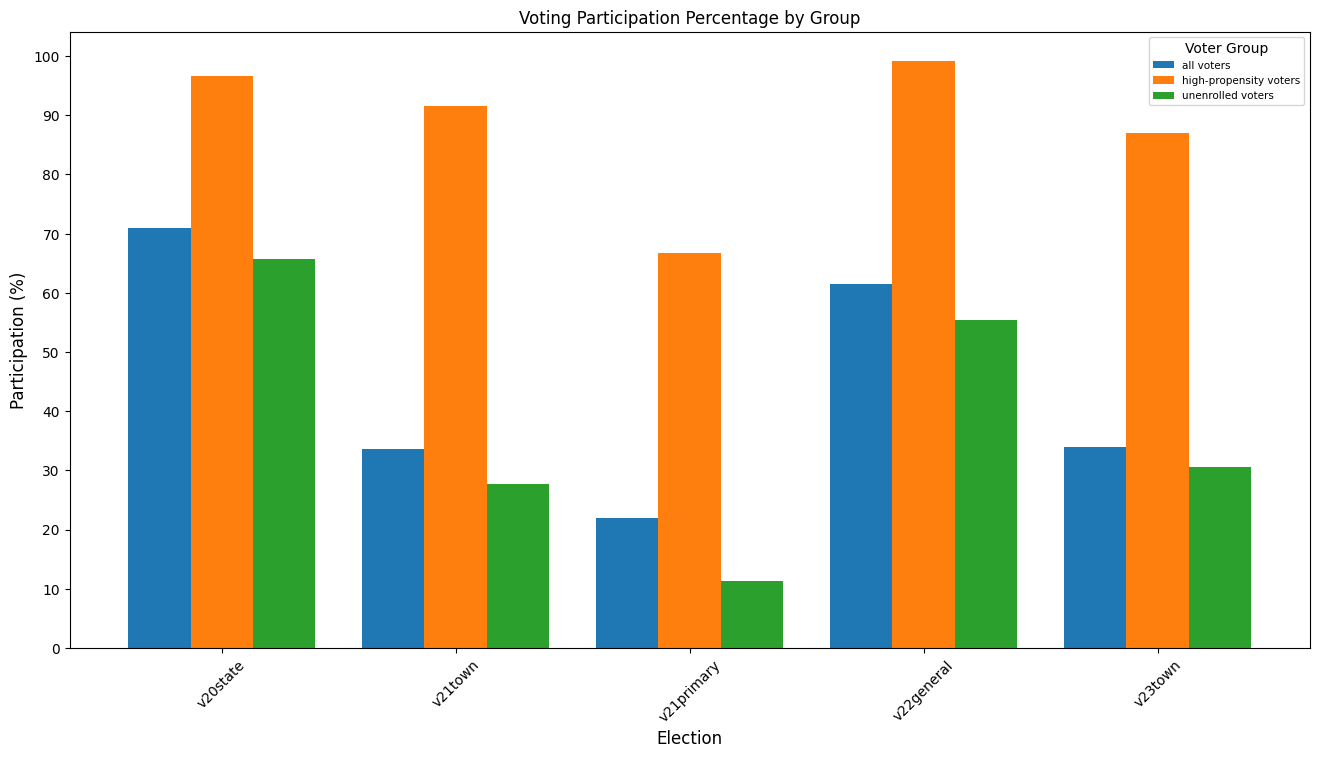

In [130]:
# Pulling election-related columns
election_columns = [col for col in df_voter_data.columns
                    if "v" in col.lower() and "score" not in col.lower()]

# participation % for all voters
d1 = (df_voter_data[election_columns] == 1).sum() / len(df_voter_data) * 100

# high voter score group
df_high_voter_score = df_voter_data[df_voter_data["voter_score"] >= 4]
print(f'Number of High Voter Score: {len(df_high_voter_score)}')

#participation % for high voter score group
d2 = (df_high_voter_score[election_columns] == 1).sum() / len(df_high_voter_score) * 100 # the voter participation for this specific group 

#unenrolled voters
df_unenrolled = df_voter_data[df_voter_data["Party Affiliation"] == "U "] # there is an uninteded space in the U values 
print(f'Number of Unenrolled: {len(df_unenrolled)}')

#participation % for unenrolled voters
d3 = (df_unenrolled[election_columns] == 1).sum() / len(df_unenrolled) * 100 # the voter participation for this specific group 


#combining into one dataframe
d = pd.DataFrame({
    "all voters": d1,
    "high-propensity voters": d2,
    "unenrolled voters": d3
})

d = d.drop(index='Voter ID Number')


#plot
d.plot(kind="bar", width = 0.8, figsize=(16,8))
plt.title("Voting Participation Percentage by Group")
plt.xlabel("Election", fontsize = 12)
plt.ylabel("Participation (%)", fontsize = 12)
plt.yticks(np.arange(0, 101, 10))
plt.xticks(rotation = 45)
plt.legend(loc = 'upper right', fontsize =7.5, title = 'Voter Group')
plt.show()


In [31]:
(df_voter_data[election_columns] == 1).sum() / len(df_voter_data) # This is the total partipation among all voters 

high_participants = df_voter_data[df_voter_data['voter_score'] >= 4] # you have to return all the columns from the original DF to get the election columns that we will use later. 


(high_participants[election_columns] == 1).sum() / len(high_participants)

# This is the percent participation of non enrolled voters 

nonenrolled_voters = df_voter_data[df_voter_data['Party Affiliation'] == 'U '] 

(nonenrolled_voters[election_columns] == 1).sum()/ len(nonenrolled_voters)






Voter ID Number    0.000000
v20state           0.656805
v21town            0.277209
v21primary         0.112475
v22general         0.554109
v23town            0.304911
dtype: float64

**Problem 12**

**Concept:** *Joining `DataFrame`s*


**Task:**

You are given two DataFrames:
* `submissions`, which contains student IDs and their homework submission IDs
* `grades`, which contains homework grades indexed by submission ID

Using these DataFrames:
1. Inspect both DataFrames by printing them.
2. Join the `submissions` DataFrame with the `grades` DataFrame:
    * Match the `hw1_submission` column in `submissions` with the index of `grades`
    * Store the result in a variable named `result`
3. Update the index of the resulting DataFrame:
    * Set the index to the `student_id` column
4. Create a new DataFrame named `result_df`:
    * Remove the `student_id` column
5. Print the final DataFrame


Starter code:

In [32]:
# STARTER CODE:
submissions = pd.DataFrame(data={"student_id": ["U100", "U101", "U102", "U103", "U104"],
                        "hw1_submission": ["c1325", "b231", "a512", "e9999", "d8234"]})

grades = pd.DataFrame(index=["a512", "b231", "c1325", "d8234", "e9999"],
                        data={"hw1_grade": [0.99, 0.50, 0.62, 0.78, 1.00]} )


In [33]:
print(submissions)
print(grades)

result = submissions.merge(grades, left_on='hw1_submission', right_index=True)
result = result.set_index('student_id')
result_df = result

print(result_df)

  student_id hw1_submission
0       U100          c1325
1       U101           b231
2       U102           a512
3       U103          e9999
4       U104          d8234
       hw1_grade
a512        0.99
b231        0.50
c1325       0.62
d8234       0.78
e9999       1.00
           hw1_submission  hw1_grade
student_id                          
U100                c1325       0.62
U101                 b231       0.50
U102                 a512       0.99
U103                e9999       1.00
U104                d8234       0.78


**Problem 13**

**Concept:** *Joining `DataFrame`s*



**Task:**

You are given two datasets:
* `design_materials.tsv`, which contains materials and the quantity required per bed
* `material_costs.tsv`, which contains the cost per unit for each material

Using these datasets:
1. Load both datasets from the provided `.tsv` files using the correct separator.
2. Merge the two DataFrames:
    * Join on the `material` column
    * Store the result in a variable named `df_costs`
3. Create a new column named `cost`:
    * Compute it as:

      **quantity_per_bed × unit_cost**
4. Print the resulting DataFrame

In [34]:
# Your Solution

df_materials = pd.read_csv('design_materials.tsv', sep='\t')

df_cost = pd.read_csv('material_costs.tsv', sep='\t')

df_costs = df_materials.merge(df_cost, on='material')

df_costs['cost'] = df_costs['quantity_per_bed'] * df_costs['unit_cost']



print(df_costs)




          design                    material  quantity_per_bed  unit_cost  \
0  4' x 4' x 18"                2" x 6" x 4'                20       5.92   
1  4' x 4' x 18"  8" x 8" x 16" Cinder Block                12       3.53   
2  4' x 8' x 18"                2" x 6" x 4'                 6       5.92   
3  4' x 8' x 18"                2" x 6" x 8'                14       7.62   
4  4' x 8' x 18"  8" x 8" x 16" Cinder Block                24       3.53   
5  4' x 4' x 12"                2" x 6" x 4'                16       5.92   
6  4' x 4' x 12"  8" x 8" x 16" Cinder Block                12       3.53   
7  4' x 8' x 12"                2" x 6" x 4'                 2       5.92   
8  4' x 8' x 12"                2" x 6" x 8'                12       7.62   
9  4' x 8' x 12"  8" x 8" x 16" Cinder Block                24       3.53   

     cost  
0  118.40  
1   42.36  
2   35.52  
3  106.68  
4   84.72  
5   94.72  
6   42.36  
7   11.84  
8   91.44  
9   84.72  


**Problem 14**

**Concept:** *joining `DataFrame`s*


**Task:**

You are given three stock datasets:
* BAC
* GM
* SBUX

Using these datasets:
1. Load each dataset into separate DataFrames:
    * `df_bac`, `df_gm`, and `df_sbux`
2. Convert the `date` column in each DataFrame to pandas datetime format and set it as the index.
3. Create a new DataFrame named `df_stock_prices`:
    * Use the index from `df_bac`
    * Add the following columns:
        * `"bac"` from `df_bac["close"]`
        * `"gm"` from `df_gm["close"]`
        * `"sbux"` from `df_sbux["close"]`
4. Create a **line plot** showing the stock prices over time.

Your plot should include:
* all three stocks on the same chart
* a title

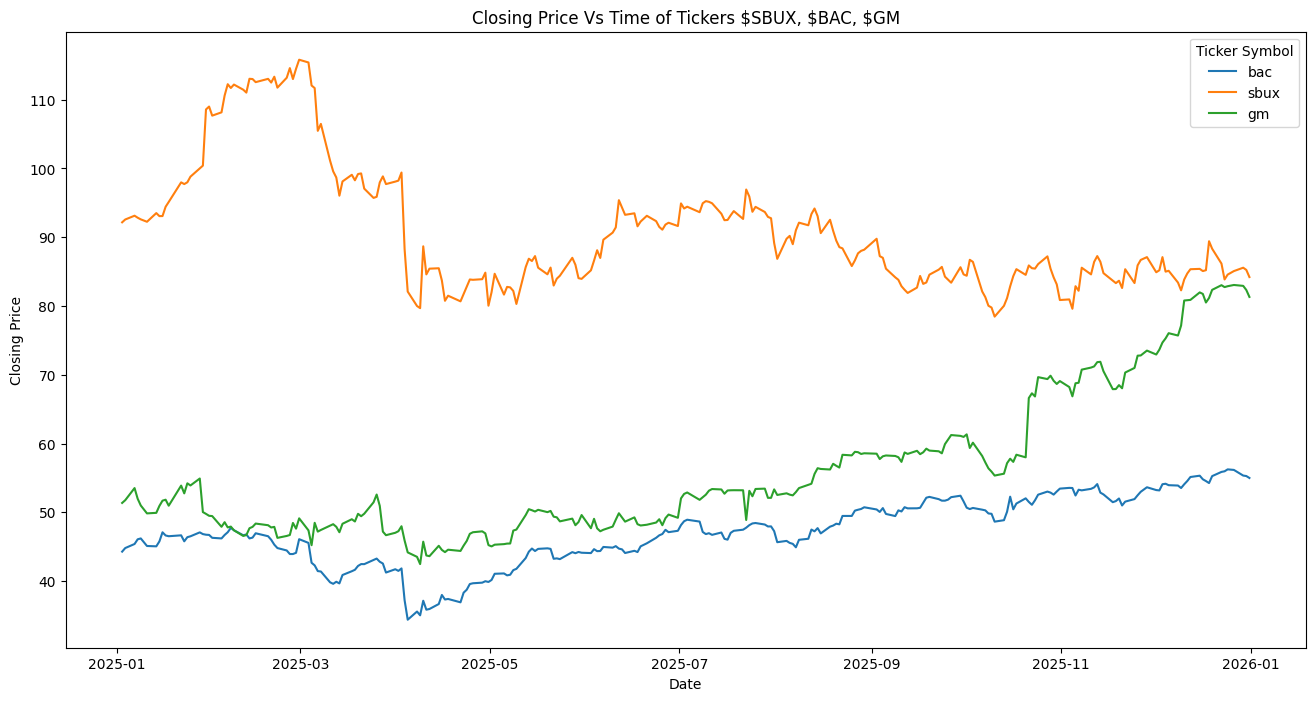

In [135]:
# Your Solution

df_BAC = pd.read_csv('BAC.csv')

df_gm = pd.read_csv('GM.csv')

df_sbux= pd.read_csv('SBUX.csv')

df_sbux["date"] = pd.to_datetime(df_sbux["date"] ,unit= 's')
df_BAC["date"] = pd.to_datetime(df_BAC["date"] ,unit= 's')
df_gm["date"] = pd.to_datetime(df_gm["date"] ,unit= 's')

df_sbux = df_sbux.set_index('date')
df_BAC = df_BAC.set_index('date')
df_gm = df_gm.set_index('date')

df_stock_prices = pd.DataFrame()

df_stock_prices['bac'] = df_BAC['close']
df_stock_prices['sbux'] = df_sbux['close']
df_stock_prices['gm'] = df_gm['close']

plt.figure(figsize=(16,8))
plt.plot(df_stock_prices)
plt.legend(df_stock_prices, title = 'Ticker Symbol')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Closing Price Vs Time of Tickers $SBUX, $BAC, $GM')
plt.show()






**Problem 15**

**Concept:** *joining `DataFrame`s*


**Task:**

Using the `df_stock_prices` DataFrame from **Problem 14**:
1. Compute the **relative prices** of each stock:
    * Divide all values by the first row of the DataFrame
    * Store the result in a variable named `df_stock_prices_relative`
2. Create a **line plot** of the relative prices.

Your plot should include:
* all three stocks on the same chart
* a title

Text(0.5, 1.0, 'Relative Price Vs Time of Tickers $SBUX, $BAC, $GM')

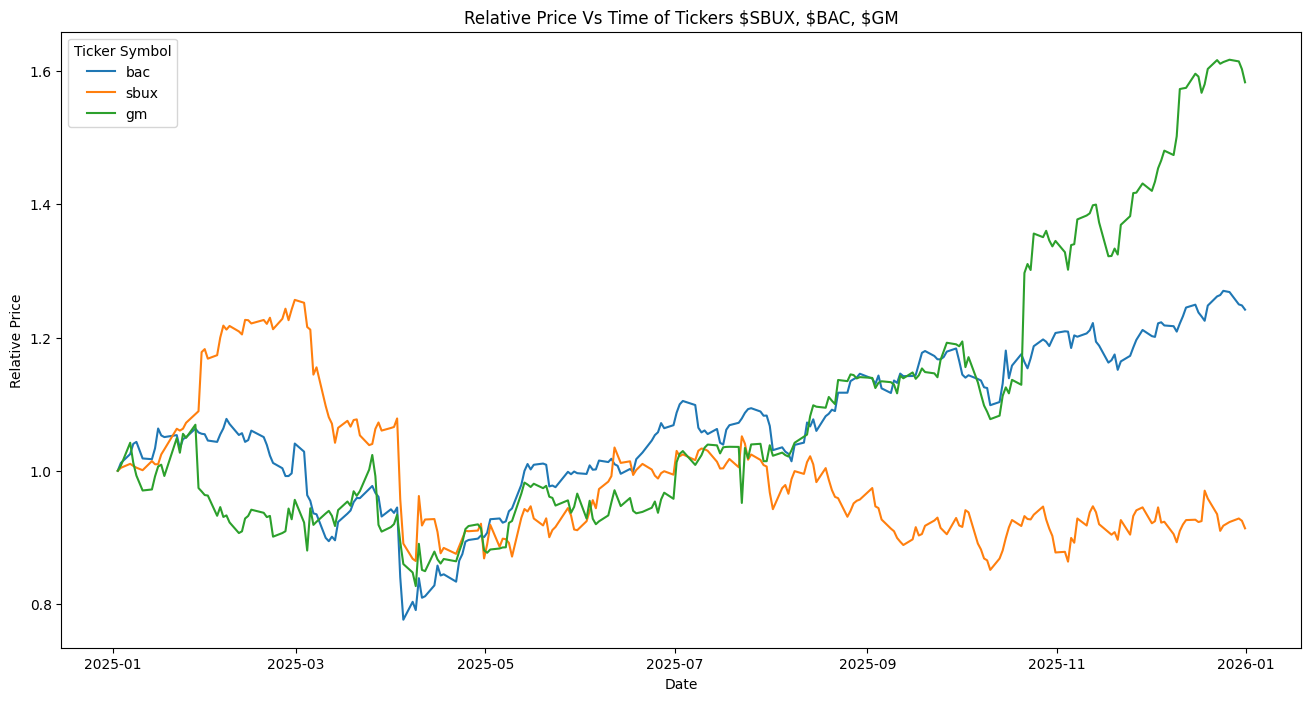

In [134]:
# Your Solution

df_stock_prices_relative = df_stock_prices / df_stock_prices.iloc[0] # dividing by the first row of the index using iloc


plt.figure(figsize=(16,8))
plt.plot(df_stock_prices_relative)
plt.legend(df_stock_prices_relative, title = 'Ticker Symbol')
plt.xlabel('Date')
plt.ylabel('Relative Price')
plt.title('Relative Price Vs Time of Tickers $SBUX, $BAC, $GM')
